# 12.5.多尺度目标检测

在 [<span style="color: #ffbf00; font-weight: bold;"> 12.4节 </span>](./12.04_anchor.ipynb)中，我们以输入图像的每个像素为中心，生成了多个锚框。基本而言，这些锚框代表了图像不同区域的样本。然而，如果为每个像素都生成的锚框，我们最终可能会得到太多需要计算的锚框。想象一个$561 \times 728$的输入图像，如果以每个像素为中心生成五个形状不同的锚框，就需要在图像上标记和预测超过200万个锚框（$561 \times 728 \times 5$）。



---


## 环境准备


In [1]:
%matplotlib inline
import os
os.environ["TILE_FWK_DEVICE_ID"] = "0"

import pypto
import torch
import torchvision
import matplotlib.pyplot as plt
from torch import nn
from src.D2LFunction import set_figsize, show_bboxes
from src.PyPTOAnchor import multibox_prior

---


## 12.5.1.多尺度锚框

减少图像上的锚框数量并不困难。比如，我们可以在输入图像中均匀采样一小部分像素，并以它们为中心生成锚框。此外，在不同尺度下，我们可以生成不同数量和不同大小的锚框。直观地说，比起较大的目标，较小的目标在图像上出现的可能性更多样。例如，$1 \times 1$、$1 \times 2$和$2 \times 2$的目标可以分别以4、2和1种可能的方式出现在$2 \times 2$图像上。因此，当使用较小的锚框检测较小的物体时，我们可以采样更多的区域，而对于较大的物体，我们可以采样较少的区域。

为了演示如何在多个尺度下生成锚框，让我们先读取一张图像。它的高度和宽度分别为561和728像素。


In [2]:
img = plt.imread('./images/catdog.jpg')
h, w = img.shape[:2]
h, w

(561, 728)

回想一下，在 [<span style="color: #ffbf00; font-weight: bold;"> 6.2节 </span>](../06_pypto_convolutional_networks/06.02_conv_layer.ipynb)中，我们将卷积图层的二维数组输出称为特征图。通过定义特征图的形状，我们可以确定任何图像上均匀采样锚框的中心。

`display_anchors`函数定义如下。我们在特征图（`fmap`）上生成锚框（`anchors`），每个单位（像素）作为锚框的中心。由于锚框中的$(x, y)$轴坐标值（`anchors`）已经被除以特征图（`fmap`）的宽度和高度，因此这些值介于0和1之间，表示特征图中锚框的相对位置。

由于锚框（`anchors`）的中心分布于特征图（`fmap`）上的所有单位，因此这些中心必须根据其相对空间位置在任何输入图像上*均匀*分布。更具体地说，给定特征图的宽度和高度`fmap_w`和`fmap_h`，以下函数将*均匀地*对任何输入图像中`fmap_h`行和`fmap_w`列中的像素进行采样。以这些均匀采样的像素为中心，将会生成大小为`s`（假设列表`s`的长度为1）且宽高比（`ratios`）不同的锚框。


In [5]:
def display_anchors(fmap_w, fmap_h, s):
    set_figsize()
    # 前两个维度上的值不影响输出
    fmap = torch.zeros((1, 10, fmap_h, fmap_w), device='npu:0')
    anchors = multibox_prior(fmap, sizes=s, ratios=[1, 2, 0.5])
    bbox_scale = torch.tensor((w, h, w, h), device='npu:0')
    show_bboxes(plt.imshow(img).axes,
                    anchors[0] * bbox_scale)

首先，让我们考虑探测小目标。为了在显示时更容易分辨，在这里具有不同中心的锚框不会重叠：锚框的尺度设置为0.15，特征图的高度和宽度设置为4。我们可以看到，图像上4行和4列的锚框的中心是均匀分布的。


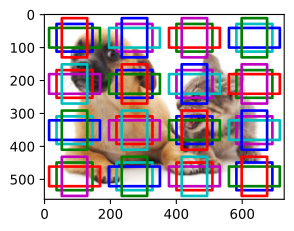

In [6]:
display_anchors(fmap_w=4, fmap_h=4, s=[0.15])

然后，我们将特征图的高度和宽度减小一半，然后使用较大的锚框来检测较大的目标。当尺度设置为0.4时，一些锚框将彼此重叠。


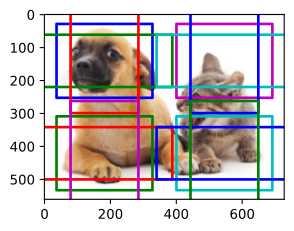

In [7]:
display_anchors(fmap_w=2, fmap_h=2, s=[0.4])

最后，我们进一步将特征图的高度和宽度减小一半，然后将锚框的尺度增加到0.8。此时，锚框的中心即是图像的中心。


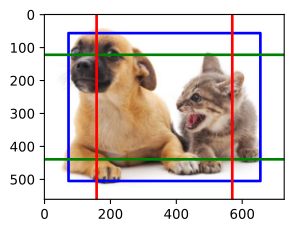

In [ ]:
display_anchors(fmap_w=1, fmap_h=1, s=[0.8])

---


## 12.5.2.多尺度检测

既然我们已经生成了多尺度的锚框，我们就将使用它们来检测不同尺度下各种大小的目标。下面，我们介绍一种基于CNN的多尺度目标检测方法，将在 [<span style="color: #ffbf00; font-weight: bold;"> 12.7节 </span>](./12.07_ssd.ipynb)中实现。

在某种规模上，假设我们有$c$张形状为$h \times w$的特征图。使用 [<span style="color: #ffbf00; font-weight: bold;"> 12.5.1节 </span>](./12.05_multiscale_object_detection.ipynb)中的方法，我们生成了$hw$组锚框，其中每组都有$a$个中心相同的锚框。例如，在 [<span style="color: #ffbf00; font-weight: bold;"> 12.5.1节 </span>](./12.05_multiscale_object_detection.ipynb)实验的第一个尺度上，给定10个（通道数量）$4 \times 4$的特征图，我们生成了16组锚框，每组包含3个中心相同的锚框。接下来，每个锚框都根据真实值边界框来标记了类和偏移量。在当前尺度下，目标检测模型需要预测输入图像上$hw$组锚框类别和偏移量，其中不同组锚框具有不同的中心。


假设此处的$c$张特征图是CNN基于输入图像的正向传播算法获得的中间输出。既然每张特征图上都有$hw$个不同的空间位置，那么相同空间位置可以看作含有$c$个单元。根据 [<span style="color: #ffbf00; font-weight: bold;"> 6.2节 </span>](../06_pypto_convolutional_networks/06.02_conv_layer.ipynb)中对感受野的定义，特征图在相同空间位置的$c$个单元在输入图像上的感受野相同：它们表征了同一感受野内的输入图像信息。因此，我们可以将特征图在同一空间位置的$c$个单元变换为使用此空间位置生成的$a$个锚框类别和偏移量。本质上，我们用输入图像在某个感受野区域内的信息，来预测输入图像上与该区域位置相近的锚框类别和偏移量。

当不同层的特征图在输入图像上分别拥有不同大小的感受野时，它们可以用于检测不同大小的目标。例如，我们可以设计一个神经网络，其中靠近输出层的特征图单元具有更宽的感受野，这样它们就可以从输入图像中检测到较大的目标。

简言之，我们可以利用深层神经网络在多个层次上对图像进行分层表示，从而实现多尺度目标检测。在 [<span style="color: #ffbf00; font-weight: bold;"> 12.7节 </span>](./12.07_ssd.ipynb)，我们将通过一个具体的例子来说明它是如何工作的。



---


## 12.5.3.小结

* 在多个尺度下，我们可以生成不同尺寸的锚框来检测不同尺寸的目标。
* 通过定义特征图的形状，我们可以决定任何图像上均匀采样的锚框的中心。
* 我们使用输入图像在某个感受野区域内的信息，来预测输入图像上与该区域位置相近的锚框类别和偏移量。
* 我们可以通过深入学习，在多个层次上的图像分层表示进行多尺度目标检测。



---


## 12.5.4.练习

1. 根据我们在 [<span style="color: #ffbf00; font-weight: bold;"> 7.1节 </span>](../07_pypto_modern_convolutional_networks/07.01_alexnet.ipynb)中的讨论，深度神经网络学习图像特征级别抽象层次，随网络深度的增加而升级。在多尺度目标检测中，不同尺度的特征映射是否对应于不同的抽象层次？为什么？
2. 在 [<span style="color: #ffbf00; font-weight: bold;"> 12.5.1节 </span>](./12.05_multiscale_object_detection.ipynb)中的实验里的第一个尺度（`fmap_w=4, fmap_h=4`）下，生成可能重叠的均匀分布的锚框。
3. 给定形状为$1 \times c \times h \times w$的特征图变量，其中$c$、$h$和$w$分别是特征图的通道数、高度和宽度。怎样才能将这个变量转换为锚框类别和偏移量？输出的形状是什么？


参考答案详见 [answers/12.05_reference_answer](./answers/12.05_reference_answer.ipynb)。

### 12.5.4.1.参考答案（PyPTO）


In [ ]:
!cat answers/txt/12.05_reference_answer_pypto.txt

### 12.5.4.2.参考答案（PyTorch）


In [ ]:
!cat answers/txt/12.05_reference_answer_pytorch.txt